# Diabetes Risk Prediction

---

## Feature Dictionary

| Feature | Type | What it represents |
|---|---|---|
| `Diabetes_binary` | Target | 0 = No diabetes, 1 = Pre-diabetes or diabetes |
| `HighBP`, `HighChol`, `CholCheck` | Binary | Blood pressure and cholesterol status |
| `BMI` | Continuous | Body Mass Index |
| `Smoker`, `Stroke`, `HeartDiseaseorAttack` | Binary | Medical history |
| `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump` | Binary | Lifestyle habits |
| `AnyHealthcare`, `NoDocbcCost` | Binary | Healthcare access |
| `GenHlth` | Ordinal 1–5 | Self-rated health (1=Excellent, 5=Poor) |
| `MentHlth`, `PhysHlth` | Count 0–30 | Days of poor health in last month |
| `DiffWalk` | Binary | Difficulty walking/climbing stairs |
| `Sex` | Binary | 0=Female, 1=Male |
| `Age` | Ordinal 1–13 | Age brackets (1=18–24 to 13=80+) |
| `Education` | Ordinal 1–6 | Highest education level |
| `Income` | Ordinal 1–8 | Income bracket |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss,
    roc_curve, precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
import xgboost as xgb
from sklearn.metrics import log_loss as sklearn_log_loss
import shap

np.random.seed(42)
print("All imports done.")
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from scipy import stats
from sklearn.model_selection import validation_curve


All imports done.


## 2. Load & Check Data

In [2]:
df = pd.read_csv('diabetes.csv')
print("Shape:", df.shape)
df.head()

Shape: (253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


### Duplicates & Missing Values

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print("Class distribution:")
print(df['Diabetes_binary'].value_counts())
print()
print("Imbalance ratio:", round(df['Diabetes_binary'].value_counts()[0] / df['Diabetes_binary'].value_counts()[1], 1), ":1")

Missing values: 0
Duplicate rows: 24206

Class distribution:
0    218334
1     35346
Name: Diabetes_binary, dtype: int64

Imbalance ratio: 6.2 :1


No missing values, no imputation needed. Class split is roughly 6:1 — majority has no diabetes.

A model that always predicts "no diabetes" would look accurate but is useless. We handle the imbalance with class weights, not SMOTE — most features here are binary, so interpolating between 0 and 1 produces values like 0.5 for `Stroke` or `Smoker`, which is meaningless.

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print("After removing duplicates:", df.shape)

After removing duplicates: (229474, 22)


### Leakage Check — CholCheck & AnyHealthcare

The test: is this feature observable before any diagnosis is made?

**`CholCheck`** — self-reported behaviour, not a test result. Available at screening. Keep.

**`AnyHealthcare`** — insurance status is known before any test is run. Some reverse causality risk (sick people seek coverage), but coverage precedes and enables diagnosis, not the other way around. Keep — but watch its SHAP rank. Top 3 globally = remove it.

Actual leakage would be post-diagnosis lab codes, prescriptions, or ICD flags. None of those are in this dataset.

In [6]:
for feat in ['CholCheck', 'AnyHealthcare']:
    rates = df.groupby(feat)['Diabetes_binary'].mean()
    print(f"{feat}: diabetes rate -> {dict(rates.round(3))}")
print()
print("High rate difference = potential leakage proxy — watch SHAP weights.")

CholCheck: diabetes rate -> {0: 0.026, 1: 0.158}
AnyHealthcare: diabetes rate -> {0: 0.115, 1: 0.155}

High rate difference = potential leakage proxy — watch SHAP weights.


## 3. Exploratory Data Analysis

### Diabetes rate by binary features

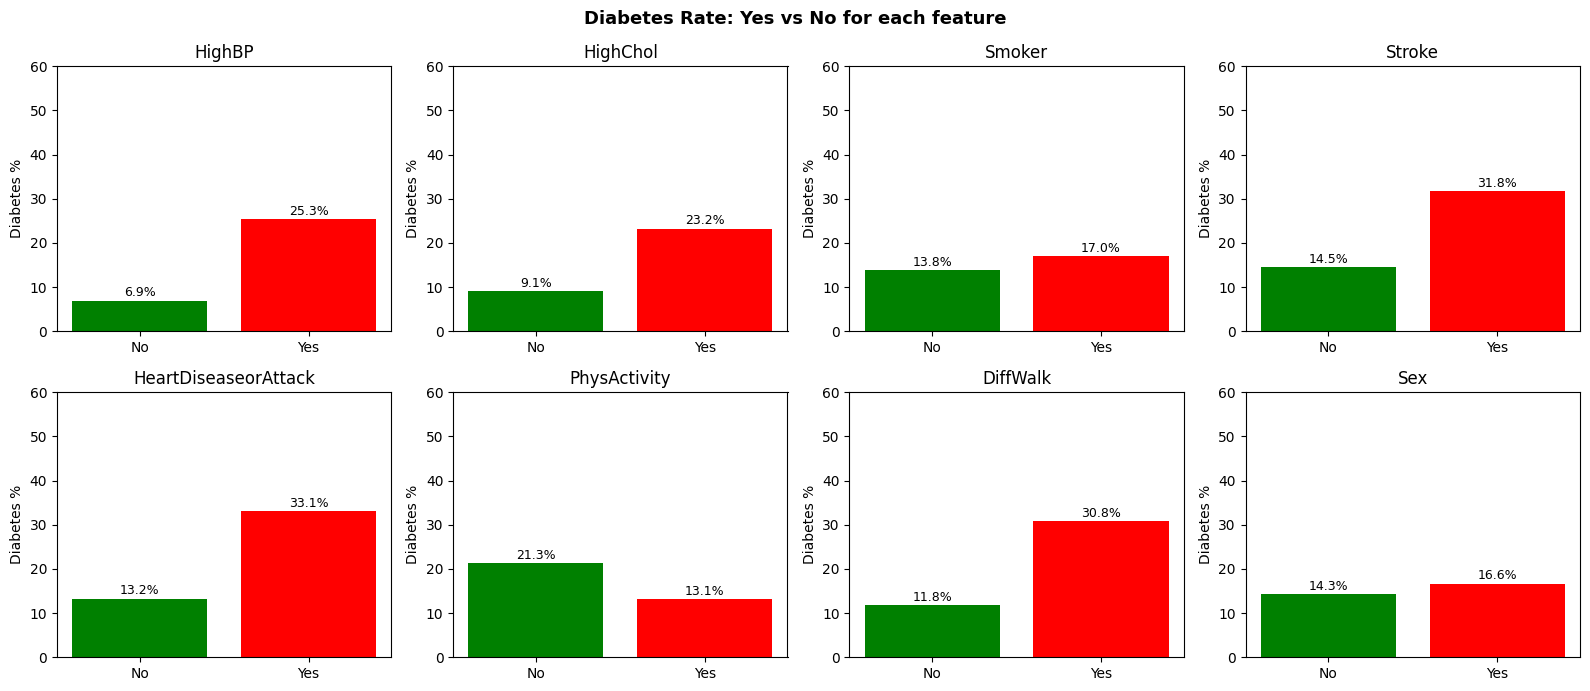

In [7]:
binary_features = ['HighBP', 'HighChol', 'Smoker', 'Stroke',
                   'HeartDiseaseorAttack', 'PhysActivity', 'DiffWalk', 'Sex']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, feat in zip(axes.flat, binary_features):
    rates = df.groupby(feat)['Diabetes_binary'].mean() * 100
    ax.bar(['No', 'Yes'], rates.values, color=['green', 'red'])
    ax.set_title(feat)
    ax.set_ylabel('Diabetes %')
    ax.set_ylim(0, 60)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Diabetes Rate: Yes vs No for each feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Diabetes rate by ordinal features

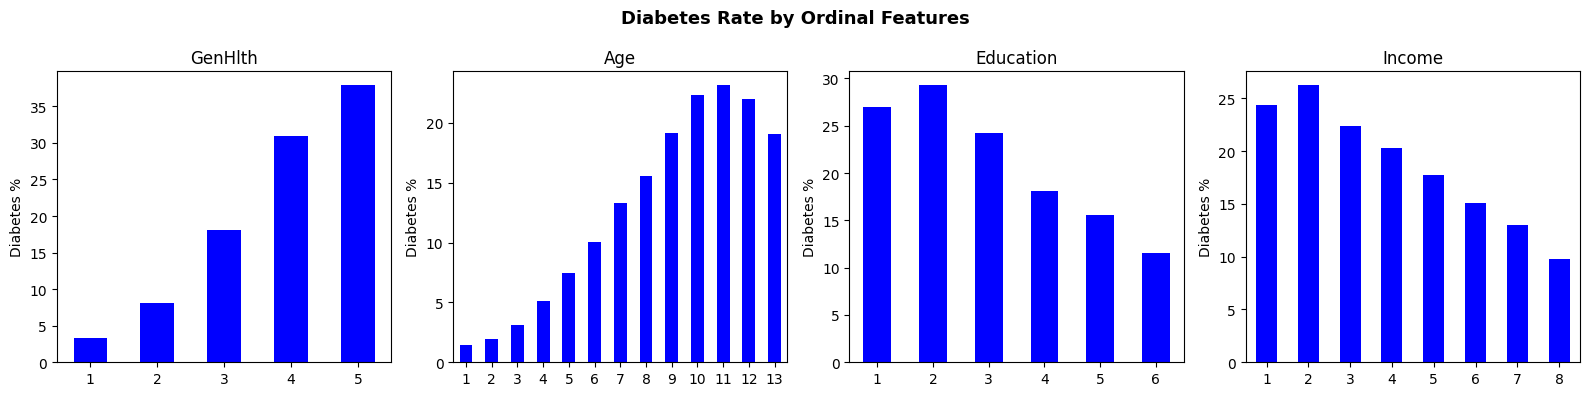

In [8]:
ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat in zip(axes, ordinal_features):
    df.groupby(feat)['Diabetes_binary'].mean().mul(100).plot(kind='bar', ax=ax, color='blue')
    ax.set_title(feat)
    ax.set_ylabel('Diabetes %')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Diabetes Rate by Ordinal Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation heatmap

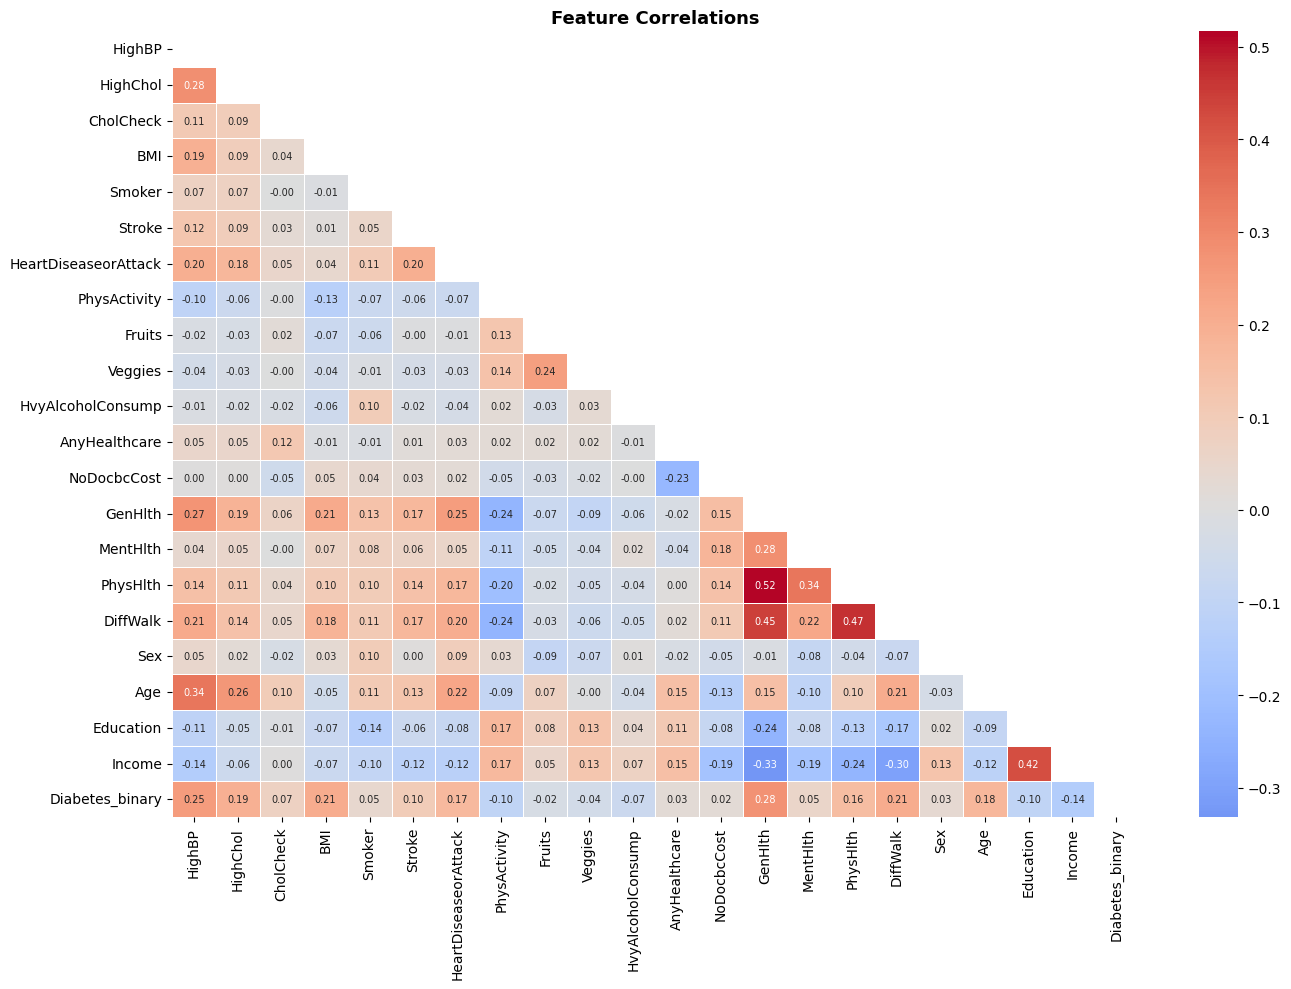

In [9]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Feature Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Pearson correlation assumes continuous, roughly normal data — most features here are binary or ordinal, so it underestimates non-linear associations. The heatmap gives a quick overview. Mutual information below is the more appropriate measure for this feature set.

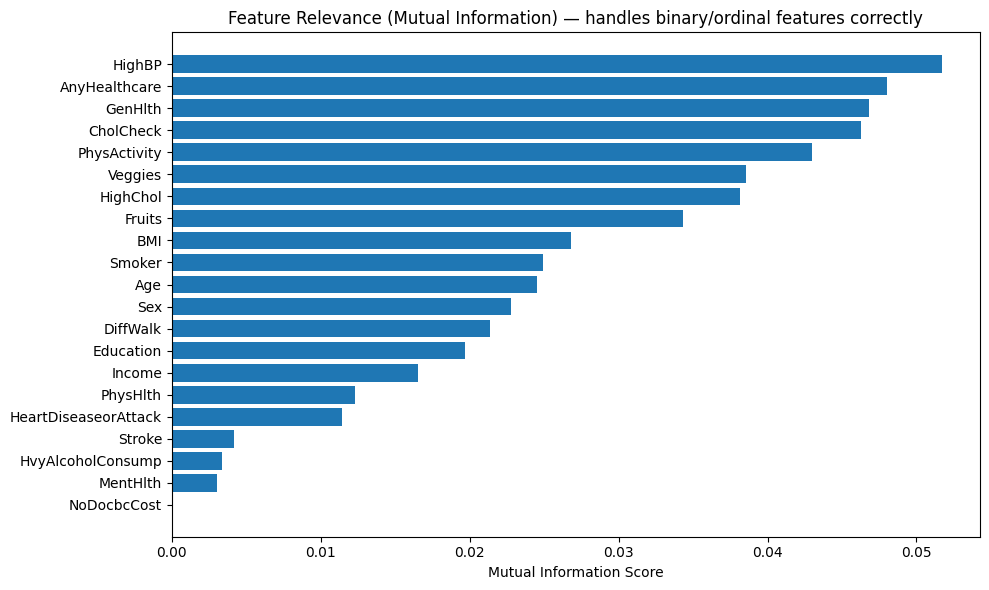

In [10]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(df.drop('Diabetes_binary', axis=1), df['Diabetes_binary'], random_state=42)
mi_df = pd.DataFrame({'Feature': df.drop('Diabetes_binary', axis=1).columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'][::-1], mi_df['MI Score'][::-1])
plt.xlabel('Mutual Information Score')
plt.title('Feature Relevance (Mutual Information) — handles binary/ordinal features correctly')
plt.tight_layout()
plt.show()

Features with MI near zero carry negligible unique signal — anything below 0.001 is a removal candidate. Use this alongside SHAP later: features that rank high in both are the most reliable. High MI but low SHAP usually means another correlated feature is absorbing the signal.

## 4. Preprocessing

Binary features are already 0/1 — no change needed. Continuous features (`BMI`, `MentHlth`, `PhysHlth`) get standardised for the linear model. Ordinal features (`Age`, `GenHlth`, etc.) stay numeric — one-hot encoding would destroy the ordering and blow up the feature space.

### Feature Engineering

A few additions that make physical sense:

- **BMI categories** — the risk relationship isn't linear. Obese vs overweight matters more than equal numeric steps.
- **Age × BMI** — these two compound each other in a way neither captures alone.
- **TotalPoorHealth** — MentHlth + PhysHlth as a single burden score.
- **Log transforms** — MentHlth and PhysHlth are right-skewed counts. Log stabilises the distribution.

In [11]:
df['BMI_cat'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 35, 200],
                        labels=[0, 1, 2, 3, 4]).astype(float)
df['Age_BMI'] = df['Age'] * df['BMI']
df['TotalPoorHealth'] = df['MentHlth'] + df['PhysHlth']
df['LogMentHlth'] = np.log1p(df['MentHlth'])
df['LogPhysHlth'] = np.log1p(df['PhysHlth'])

print('New features:', ['BMI_cat', 'Age_BMI', 'TotalPoorHealth', 'LogMentHlth', 'LogPhysHlth'])
print('New shape:', df.shape)

New features: ['BMI_cat', 'Age_BMI', 'TotalPoorHealth', 'LogMentHlth', 'LogPhysHlth']
New shape: (229474, 27)


In [12]:
# Validate BMI binning: verify diabetes rate monotonically increases
bmi_rates = df.groupby('BMI_cat', observed=True)['Diabetes_binary'].agg(['mean', 'count'])
bmi_rates.columns = ['Diabetes Rate', 'Count']
bmi_rates.index = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II+']
print('Diabetes rate by BMI category:')
print(bmi_rates.round(3))

from scipy.stats import chi2_contingency, spearmanr
contingency = pd.crosstab(df['BMI_cat'], df['Diabetes_binary'])
chi2, p_chi2, _, _ = chi2_contingency(contingency)
print(f'\nChi-squared test (BMI_cat vs Diabetes): chi2={chi2:.1f}, p={p_chi2:.2e}')
print('Significant p confirms diabetes rate differs across BMI categories')

rho, p_sp = spearmanr(df['BMI_cat'].astype(float), df['Diabetes_binary'])
print(f'Spearman rho (BMI_cat vs Diabetes): rho={rho:.4f}, p={p_sp:.2e}')
print('Positive rho = monotonic relationship — ordinal binning captures true ordering')

Diabetes rate by BMI category:
             Diabetes Rate  Count
Underweight          0.055   3052
Normal               0.073  73635
Overweight           0.140  81414
Obese I              0.219  42696
Obese II+            0.308  28677

Chi-squared test (BMI_cat vs Diabetes): chi2=10709.0, p=0.00e+00
Significant p confirms diabetes rate differs across BMI categories
Spearman rho (BMI_cat vs Diabetes): rho=0.2104, p=0.00e+00
Positive rho = monotonic relationship — ordinal binning captures true ordering


In [13]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

continuous_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age_BMI',
                   'TotalPoorHealth', 'LogMentHlth', 'LogPhysHlth']
scaler = StandardScaler()

# Linear models: scaled
X_train_lr = X_train_raw.copy()
X_test_lr  = X_test_raw.copy()
X_train_lr[continuous_cols] = scaler.fit_transform(X_train_lr[continuous_cols])
X_test_lr[continuous_cols]  = scaler.transform(X_test_lr[continuous_cols])

# Tree models: raw (no scaling needed — splits are rank-based)
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)
print('Positive rate in train:', round(y_train.mean(), 3))
print('LR: X_train_lr / X_test_lr (scaled) | RF, XGBoost: X_train / X_test (raw)')

Train size: (183579, 26)
Test size:  (45895, 26)
Positive rate in train: 0.153
LR: X_train_lr / X_test_lr (scaled) | RF, XGBoost: X_train / X_test (raw)


### Algorithm Selection

**We have imbalanced data**

- **Logistic Regression**-– Simple, interpretable, and works well as a baseline  
- **Random Forest**-------– Handles mixed feature types robustly and is less sensitive to scaling  
- **XGBoost**-------–------ Typically performs best on tabular data and can handle imbalance effectively  
- **SVM**-------–-------–-- Poor scalability for ~230k rows; computationally expensive  
- **KNN**-------–-------–-– Not meaningful here; distance between binary feature vectors is not informative  
- **Naive Bayes**-------–-– Assumes feature independence, which is unrealistic for this dataset  
- **Neural Networks**-----– Generally underperform on structured survey/tabular data without significant tuning  

### Why these three models

With 230k rows and mostly binary features, the realistic options are:

- **Logistic Regression** — fast, interpretable, gives odds ratios. Good baseline.
- **Random Forest** — handles mixed features well, not sensitive to scale.
- **XGBoost** — best in practice on tabular data, handles imbalance natively.

SVM and KNN don't scale. Naive Bayes assumes feature independence (unrealistic here). Neural nets generally underperform on structured survey data without heavy tuning.

## 4b. Baselines First

Before training anything real, what does a dumb model score? The no-skill PR-AUC floor is just `y.mean()` — computed below. We also test a one-liner rule (BMI high + middle-aged). If that scores 0.70 AUC, the ML pipeline needs to beat it by a meaningful margin to justify the complexity.

In [14]:
from sklearn.dummy import DummyClassifier

# Actual PR-AUC baseline = positive class prevalence
pr_auc_baseline = y.mean()
print(f'PR-AUC no-skill baseline (y.mean()): {pr_auc_baseline:.4f}')
print(f'This is the floor — all models must beat {pr_auc_baseline:.4f} on PR-AUC to be useful.')
print()

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_prob = dummy.predict_proba(X_test)[:, 1]

dummy_rand = DummyClassifier(strategy='uniform', random_state=42)
dummy_rand.fit(X_train, y_train)
dummy_rand_prob = dummy_rand.predict_proba(X_test)[:, 1]

# Simple rule: BMI_cat >= 3 AND Age >= 5
rule_prob = ((X_test['BMI_cat'] >= 3) & (X_test['Age'] >= 5)).astype(float)

print('Baseline Performance')
print('-' * 40)
for name, prob in [
    ('Majority Classifier', dummy_prob),
    ('Random Classifier', dummy_rand_prob),
    ('BMI+Age Rule', rule_prob),
]:
    try:
        roc = roc_auc_score(y_test, prob)
    except Exception:
        roc = float('nan')
    pr = average_precision_score(y_test, prob)
    print(f'  {name:25s}: ROC={roc:.3f}  PR-AUC={pr:.3f}')
print()
print('Our ML models need to beat all of these.')

PR-AUC no-skill baseline (y.mean()): 0.1529
This is the floor — all models must beat 0.1529 on PR-AUC to be useful.

Baseline Performance
----------------------------------------
  Majority Classifier      : ROC=0.500  PR-AUC=0.153
  Random Classifier        : ROC=0.500  PR-AUC=0.153
  BMI+Age Rule             : ROC=0.636  PR-AUC=0.218

Our ML models need to beat all of these.


## 5. Training

Three models, each with imbalance handling built in via `class_weight` or `scale_pos_weight`. LR trains on scaled features; RF and XGBoost train on raw features — trees don't need scaling.

In [15]:
# Logistic Regression — scaled features
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_lr, y_train)
print('Logistic Regression trained on scaled features.')

Logistic Regression trained on scaled features.


In [16]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [ ]:
# XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=neg / pos,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
print("XGBoost trained.")

XGBoost trained.


## 5b. Hyperparameter Tuning

Default params are a starting point. Optuna searches over XGBoost hyperparameters using 3-fold CV on the training set, picks the best config, then we compare it against the manual baseline on the test set.

In [18]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

neg_full = (y_train == 0).sum()
pos_full = (y_train == 1).sum()
cv_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 400, step=50),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0.0, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 1.0),
        scale_pos_weight = neg_full / pos_full,
        random_state     = 42,
        verbosity        = 0,
    )
    m = xgb.XGBClassifier(**params)
    cv_s = cross_validate(m, X_train, y_train, cv=cv_opt,
                          scoring='average_precision', n_jobs=-1)
    return cv_s['test_score'].mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)

print('Best trial:')
print(f'  PR-AUC (CV) : {study.best_value:.4f}')
print(f'  Params      : {study.best_params}')

best_p = study.best_params.copy()
best_p.update({'scale_pos_weight': neg_full / pos_full, 'random_state': 42, 'verbosity': 0})
xgb_tuned = xgb.XGBClassifier(**best_p)
xgb_tuned.fit(X_train, y_train)
print()
print('xgb_tuned trained. Comparison vs manual baseline is printed in Section 6.')


[W 2026-04-29 11:08:11,541] Trial 0 failed with parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.05808361216819946, 'reg_alpha': 0.8661761457749352} because of the following error: The value nan is not acceptable.
[W 2026-04-29 11:08:11,541] Trial 0 failed with value nan.
[W 2026-04-29 11:08:50,806] Trial 1 failed with parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 3, 'gamma': 0.18182496720710062, 'reg_alpha': 0.18340450985343382} because of the following error: The value nan is not acceptable.
[W 2026-04-29 11:08:50,806] Trial 1 failed with value nan.
[W 2026-04-29 11:09:16,482] Trial 2 failed with parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560

Best trial:


ValueError: No trials are completed yet.

### Validation curves — max_depth and n_estimators

One parameter varied at a time. Shows where performance saturates and where overfitting starts.

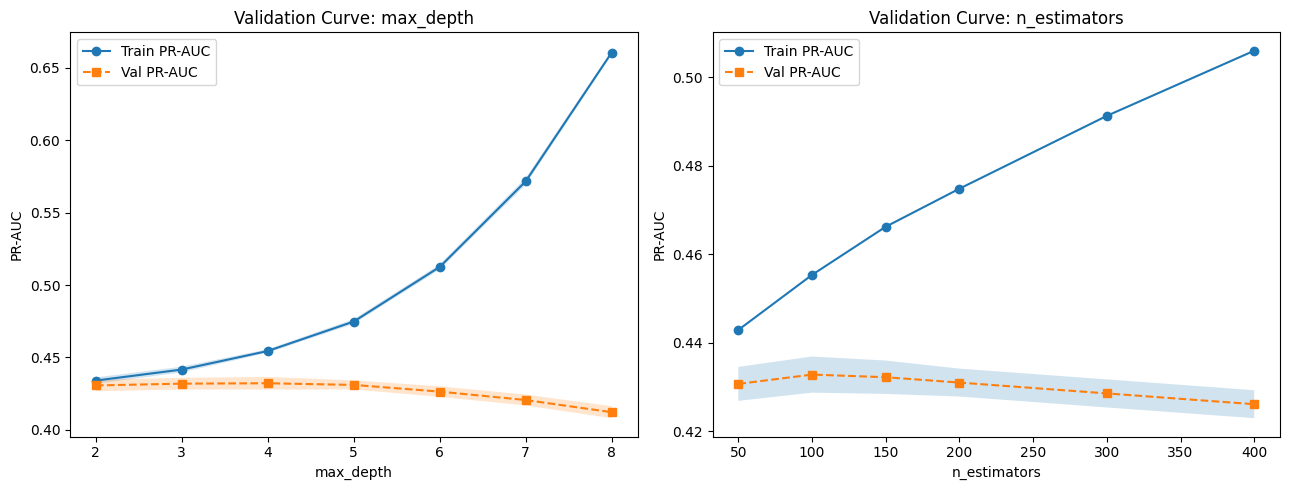

In [ ]:
from sklearn.model_selection import validation_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# max_depth
depths = [2, 3, 4, 5, 6, 7, 8]
xgb_vc = xgb.XGBClassifier(
    scale_pos_weight=neg_full/pos_full, n_estimators=200,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
train_sc, val_sc = validation_curve(
    xgb_vc, X_train, y_train, param_name='max_depth',
    param_range=depths, cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='average_precision', n_jobs=-1
)
axes[0].plot(depths, train_sc.mean(axis=1), 'o-', label='Train PR-AUC')
axes[0].fill_between(depths,
    train_sc.mean(axis=1) - train_sc.std(axis=1),
    train_sc.mean(axis=1) + train_sc.std(axis=1), alpha=0.2)
axes[0].plot(depths, val_sc.mean(axis=1), 's--', label='Val PR-AUC')
axes[0].fill_between(depths,
    val_sc.mean(axis=1) - val_sc.std(axis=1),
    val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.2)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('Validation Curve: max_depth')
axes[0].legend()

# n_estimators
n_est = [50, 100, 150, 200, 300, 400]
xgb_vc2 = xgb.XGBClassifier(
    scale_pos_weight=neg_full/pos_full, max_depth=5,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
train_sc2, val_sc2 = validation_curve(
    xgb_vc2, X_train, y_train, param_name='n_estimators',
    param_range=n_est, cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='average_precision', n_jobs=-1
)
axes[1].plot(n_est, train_sc2.mean(axis=1), 'o-', label='Train PR-AUC')
axes[1].plot(n_est, val_sc2.mean(axis=1),   's--', label='Val PR-AUC')
axes[1].fill_between(n_est,
    val_sc2.mean(axis=1) - val_sc2.std(axis=1),
    val_sc2.mean(axis=1) + val_sc2.std(axis=1), alpha=0.2)
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('Validation Curve: n_estimators')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Evaluating All Models

**ROC-AUC** is a ranking metric. For imbalanced data it can look good even when the model misses most positive cases — it credits the model for correctly ordering the abundant negatives. Don't rely on it alone here.

**PR-AUC** focuses entirely on the minority class. It's harder to inflate and directly measures how useful the model is for catching diabetes cases. This is the primary metric.

**Log Loss** penalises confident wrong predictions — relevant when the actual probability matters, not just the label.

In [ ]:
models_test_data = {
    'Logistic Regression': (lr,        X_test_lr),
    'Random Forest':       (rf,        X_test),
    'XGBoost':             (xgb_model, X_test),
}

scores = {}
for name, (model, X_ev) in models_test_data.items():
    proba = model.predict_proba(X_ev)[:, 1]
    scores[name] = {
        'ROC-AUC':  roc_auc_score(y_test, proba),
        'PR-AUC':   average_precision_score(y_test, proba),
        'Log Loss': log_loss(y_test, proba),
        'proba':    proba
    }

results_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != 'proba'}
    for name, vals in scores.items()
}).T.round(4)
print(results_df.to_string())

print()
print('Manual XGBoost vs Tuned XGBoost on test set')
print('-' * 50)
tuned_proba = xgb_tuned.predict_proba(X_test)[:, 1]
for label, prob in [('Manual', scores['XGBoost']['proba']), ('Tuned ', tuned_proba)]:
    print(f'  {label}: ROC={roc_auc_score(y_test, prob):.4f}'
          f'  PR-AUC={average_precision_score(y_test, prob):.4f}'
          f'  LogLoss={log_loss(y_test, prob):.4f}')

print()
print('Bias-variance reasoning:')
print('  LR      : high bias (linear boundary) — underfits if interactions exist, low variance')
print('  RF      : lower bias via averaging, variance controlled by depth/n_estimators')
print('  XGBoost : lowest bias (boosts residuals), highest variance risk — regularised via subsample/colsample')
print('  Winner on PR-AUC = best at catching minority class. Loser on Log Loss = overconfident probabilities.')

                     ROC-AUC  PR-AUC  Log Loss
Logistic Regression   0.8128  0.4244    0.5418
Random Forest         0.8144  0.4352    0.5334
XGBoost               0.8181  0.4442    0.5242

Manual XGBoost vs Tuned XGBoost on test set
--------------------------------------------------
  Manual: ROC=0.8181  PR-AUC=0.4442  LogLoss=0.5242
  Tuned : ROC=0.8194  PR-AUC=0.4468  LogLoss=0.5240


### ROC and Precision-Recall Curves

### Cross-Validation + Confidence Intervals

A single test split is noisy. 5-fold CV gives a distribution; bootstrap gives 95% CIs on the test set. If the CI is wide, the estimate is unreliable — not a property of the model, just a small test set.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': (lr,        X_train_lr, y_train),
    'Random Forest':       (rf,        X_train,    y_train),
    'XGBoost':             (xgb_model, X_train,    y_train),
}

print('5-Fold CV PR-AUC (primary metric for imbalanced data)')
print('-' * 55)
cv_results = {}
for name, (model, Xc, yc) in models_cv.items():
    result = cross_validate(model, Xc, yc, cv=cv,
                            scoring='average_precision', n_jobs=-1)
    s_cv = result['test_score']
    cv_results[name] = s_cv
    print(f'  {name:25s}: {s_cv.mean():.4f} ± {s_cv.std():.4f}')

print()
print('Bootstrap 95% CI — XGBoost (ROC-AUC, PR-AUC, Log Loss)')
print('-' * 60)
n_boot = 500
boot_roc, boot_pr, boot_ll = [], [], []
xgb_proba_all = scores['XGBoost']['proba']
rng_boot = np.random.RandomState(42)
for _ in range(n_boot):
    idx = rng_boot.choice(len(y_test), len(y_test), replace=True)
    ys, ps = y_test.values[idx], xgb_proba_all[idx]
    if len(np.unique(ys)) < 2:
        continue
    boot_roc.append(roc_auc_score(ys, ps))
    boot_pr.append(average_precision_score(ys, ps))
    boot_ll.append(log_loss(ys, ps))

for label, vals in [('ROC-AUC ', boot_roc), ('PR-AUC  ', boot_pr), ('Log Loss', boot_ll)]:
    lo, hi = np.percentile(vals, [2.5, 97.5])
    print(f'  {label}: mean={np.mean(vals):.4f}  95% CI: [{lo:.4f}, {hi:.4f}]')

print()
print('Narrow CI = stable estimate. Wide CI = test set too small to resolve true performance.')
print('PR-AUC CI bounds real-world minority-class performance — this is the number to report.')

5-Fold CV ROC-AUC
---------------------------------------------
  Logistic Regression      : 0.8093 ± 0.0013
  Random Forest            : 0.8098 ± 0.0013
  XGBoost                  : 0.8144 ± 0.0010

Bootstrap 95% CI — XGBoost (ROC-AUC, PR-AUC, Log Loss)
------------------------------------------------------------
  ROC-AUC : mean=0.8180  95% CI: [0.8135, 0.8225]
  PR-AUC  : mean=0.4443  95% CI: [0.4332, 0.4567]
  Log Loss: mean=0.5243  95% CI: [0.5203, 0.5289]

PR-AUC CI matters more here than ROC-AUC — minority class is what we care about.


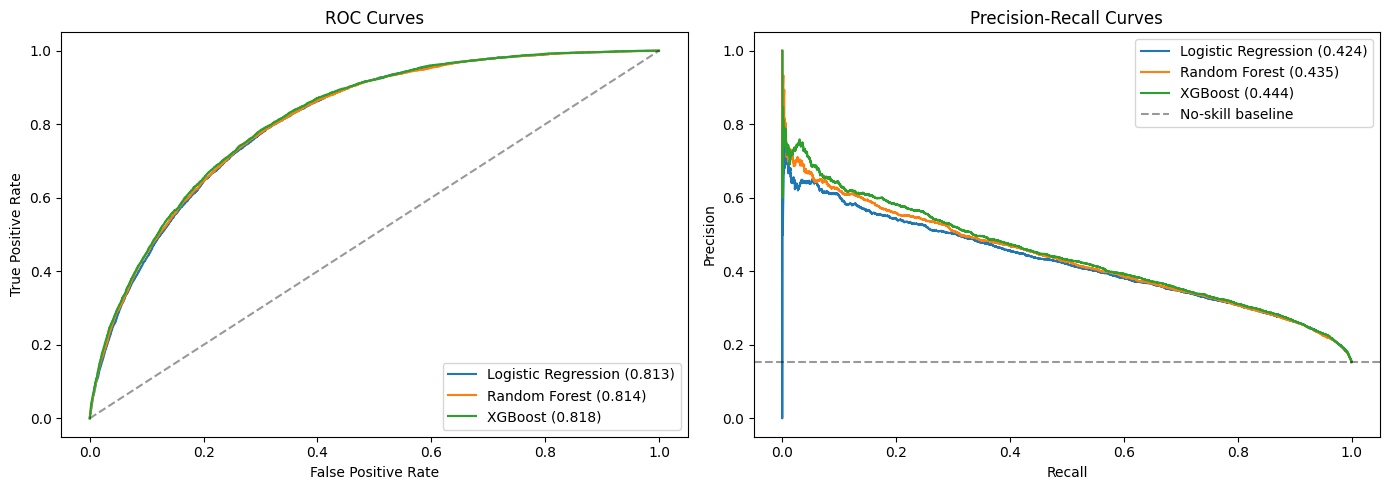

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, vals in scores.items():
    fpr, tpr, _ = roc_curve(y_test, vals['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} ({vals['ROC-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

for name, vals in scores.items():
    prec, rec, _ = precision_recall_curve(y_test, vals['proba'])
    axes[1].plot(rec, prec, label=f"{name} ({vals['PR-AUC']:.3f})")

axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label='No-skill baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Calibration

If the model says 70% chance of diabetes, does that actually happen 70% of the time?

A well-calibrated model tracks the diagonal. Below it = overconfident. Above it = underconfident. In a medical context this matters — a doctor acting on probability scores needs those scores to be honest.

## 7b. Threshold Selection

Default threshold of 0.5 is almost always wrong for medical screening. Missing a diabetic (false negative) means untreated disease. A false positive means a follow-up test — inconvenient, not dangerous.

**Objective:** maximise recall subject to precision ≥ 0.30. At least 30% of flagged patients should actually have diabetes — anything lower floods clinics with false alarms.

Threshold is tuned on a held-out validation set. Test set is untouched throughout.

In [ ]:
# Threshold tuned on validation — test set never touched here
X_thresh_tr, X_thresh_val, y_thresh_tr, y_thresh_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=7, stratify=y_train
)
neg_t = (y_thresh_tr == 0).sum(); pos_t = (y_thresh_tr == 1).sum()
xgb_thresh = xgb.XGBClassifier(
    scale_pos_weight=neg_t/pos_t, n_estimators=200, max_depth=5,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_thresh.fit(X_thresh_tr, y_thresh_tr)
val_proba = xgb_thresh.predict_proba(X_thresh_val)[:, 1]

thresholds = np.linspace(0.05, 0.95, 200)
cost_ratios = [1, 3, 5, 10]

optimal_thresholds = {}
print('Threshold tuning on VALIDATION set — minimise expected cost')
print('-' * 55)
for ratio in cost_ratios:
    best_thresh, best_cost = 0.5, float('inf')
    for t in thresholds:
        preds = (val_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_thresh_val, preds).ravel()
        cost = ratio * fn + fp
        if cost < best_cost:
            best_cost = cost
            best_thresh = t
    optimal_thresholds[ratio] = best_thresh
    print(f'  c_FN/c_FP={ratio:2d}  best threshold on val = {best_thresh:.2f}')

xgb_proba_test = scores['XGBoost']['proba']
print()
print('Performance on TEST set at validation-tuned thresholds')
print('-' * 60)
for ratio, thresh in optimal_thresholds.items():
    preds_opt = (xgb_proba_test >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_opt).ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f'  c_FN/c_FP={ratio:2d}  threshold={thresh:.2f}  '
          f'recall={recall:.3f}  precision={precision:.3f}  FN={fn}  FP={fp}')

print()
print('Default 0.5 on test:')
preds_default = (xgb_proba_test >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, preds_default).ravel()
print(f'  FN={fn}  FP={fp}  Recall={tp/(tp+fn):.3f}  Precision={tp/(tp+fp):.3f}')

# Precision-constrained objective: maximise recall s.t. precision >= 0.30
print()
print('Precision-constrained threshold (maximise recall, precision >= 0.30):')
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_thresh_val, val_proba)
valid_mask = prec_arr[:-1] >= 0.30
if valid_mask.any():
    best_idx = np.argmax(rec_arr[:-1][valid_mask])
    pc_thresh = thr_arr[valid_mask][best_idx]
    preds_pc = (xgb_proba_test >= pc_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_pc).ravel()
    recall_pc    = tp / (tp + fn)
    precision_pc = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f'  threshold={pc_thresh:.3f}  recall={recall_pc:.3f}  precision={precision_pc:.3f}  FN={fn}  FP={fp}')
else:
    print('  No threshold achieves precision >= 0.30 on validation set')

Threshold tuning on VALIDATION set
-------------------------------------------------------
  c_FN/c_FP= 1  best threshold on val = 0.86
  c_FN/c_FP= 3  best threshold on val = 0.62
  c_FN/c_FP= 5  best threshold on val = 0.50
  c_FN/c_FP=10  best threshold on val = 0.34

Performance on TEST set at validation-tuned thresholds
------------------------------------------------------------
  c_FN/c_FP= 1  threshold=0.86  recall=0.121  precision=0.619  FN=6171  FP=522
  c_FN/c_FP= 3  threshold=0.62  recall=0.633  precision=0.380  FN=2578  FP=7255
  c_FN/c_FP= 5  threshold=0.50  recall=0.784  precision=0.320  FN=1515  FP=11688
  c_FN/c_FP=10  threshold=0.34  recall=0.905  precision=0.261  FN=668  FP=17953

Default 0.5 on test:
  FN=1501  FP=11772  Recall=0.786  Precision=0.319


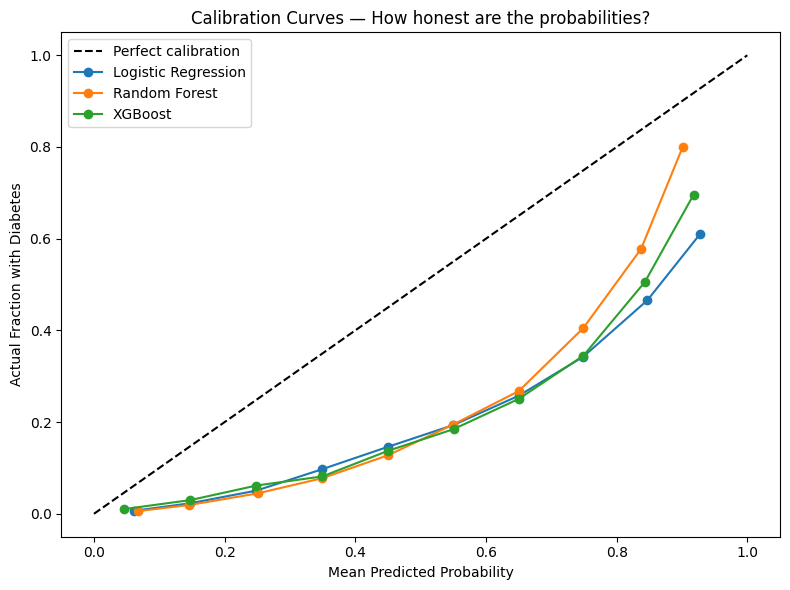

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

for name, vals in scores.items():
    frac_pos, mean_pred = calibration_curve(y_test, vals['proba'], n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Fraction with Diabetes')
plt.title('Calibration Curves — How honest are the probabilities?')
plt.legend()
plt.tight_layout()
plt.show()

# Quantify miscalibration: Expected Calibration Error (ECE)
print('Expected Calibration Error (ECE) — weighted mean |predicted - actual| across bins:')
print('-' * 55)
bin_edges = np.linspace(0, 1, 11)
for name, vals in scores.items():
    proba = vals['proba']
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ece = 0.0
    for mp, fp_bin in zip(mean_pred, frac_pos):
        # Find bin index for this mean_pred value
        n_bin = ((proba >= mp - 0.05) & (proba < mp + 0.05)).sum()
        ece += (n_bin / len(proba)) * abs(mp - fp_bin)
    # Direction: compare last bin (highest probs)
    direction = 'overconfident' if mean_pred[-1] > frac_pos[-1] else 'underconfident'
    print(f'  {name:25s}: ECE={ece:.4f}  ({direction} at high-prob end)')
print()
print('Interpretation: ECE > 0.05 = substantial miscalibration. '
      'Overconfident = model predicts higher probability than observed — needs calibration.')

### Fixing Calibration

Two standard approaches:

**Platt scaling** — fits a logistic regression on top of raw scores. Fast, works on small calibration sets.
**Isotonic regression** — more flexible but needs more data.

After calibration, a 70% predicted score should correspond to ~70% actual diabetes cases.

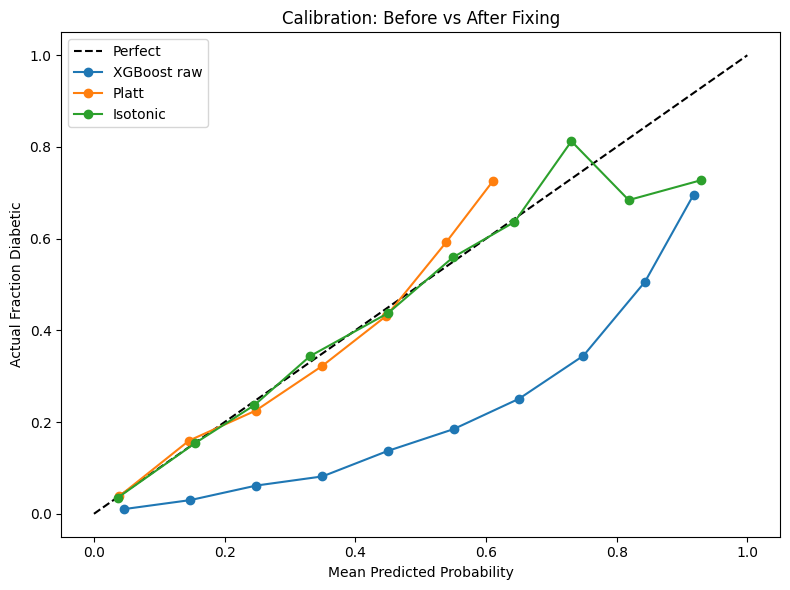

Log Loss:
  XGBoost raw    : 0.5242
  Platt          : 0.3387
  Isotonic       : 0.3409


In [ ]:
X_cal_tr, X_cal_val, y_cal_tr, y_cal_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=99, stratify=y_train
)

neg2 = (y_cal_tr == 0).sum(); pos2 = (y_cal_tr == 1).sum()
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=neg2/pos2, n_estimators=200, max_depth=5,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_base.fit(X_cal_tr, y_cal_tr)

xgb_platt = CalibratedClassifierCV(xgb_base, method='sigmoid', cv='prefit')
xgb_platt.fit(X_cal_val, y_cal_val)

xgb_iso = CalibratedClassifierCV(xgb_base, method='isotonic', cv='prefit')
xgb_iso.fit(X_cal_val, y_cal_val)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
for label, prob in [
    ('XGBoost raw', scores['XGBoost']['proba']),
    ('Platt', xgb_platt.predict_proba(X_test)[:, 1]),
    ('Isotonic', xgb_iso.predict_proba(X_test)[:, 1]),
]:
    frac, mean_p = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(mean_p, frac, marker='o', label=label)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Actual Fraction Diabetic')
ax.set_title('Calibration: Before vs After Fixing')
ax.legend()
plt.tight_layout()
plt.show()

print('Log Loss:')
for label, prob in [
    ('XGBoost raw', scores['XGBoost']['proba']),
    ('Platt', xgb_platt.predict_proba(X_test)[:, 1]),
    ('Isotonic', xgb_iso.predict_proba(X_test)[:, 1]),
]:
    print(f'  {label:15s}: {log_loss(y_test, prob):.4f}')

## 8. Logistic Regression — Odds Ratios

Each coefficient exponentiated gives an **odds ratio**: how much the odds of diabetes change per unit increase in that feature.

- OR > 1 → risk increases
- OR < 1 → risk decreases

This is what makes LR useful here — not just "this feature matters" but by exactly how much.

In [ ]:
feature_names = X_train.columns.tolist()
coefs = lr.coef_[0]
odds_ratios = np.exp(coefs)

or_df = pd.DataFrame({
    'Feature': feature_names,
    'Odds Ratio': odds_ratios
}).sort_values('Odds Ratio', ascending=False)

print(or_df.to_string(index=False))

             Feature  Odds Ratio
           CholCheck    3.696189
              HighBP    2.008754
            HighChol    1.756013
             GenHlth    1.715251
             Age_BMI    1.463189
             BMI_cat    1.379706
                 Sex    1.308233
HeartDiseaseorAttack    1.268216
              Stroke    1.184521
            DiffWalk    1.106743
            MentHlth    1.099524
       AnyHealthcare    1.096540
                 Age    1.031203
         LogPhysHlth    1.020291
         NoDocbcCost    1.007482
     TotalPoorHealth    1.003962
        PhysActivity    0.998740
             Veggies    0.991623
              Smoker    0.981128
           Education    0.979819
              Fruits    0.979046
                 BMI    0.959995
              Income    0.950891
            PhysHlth    0.927712
         LogMentHlth    0.856431
   HvyAlcoholConsump    0.459389


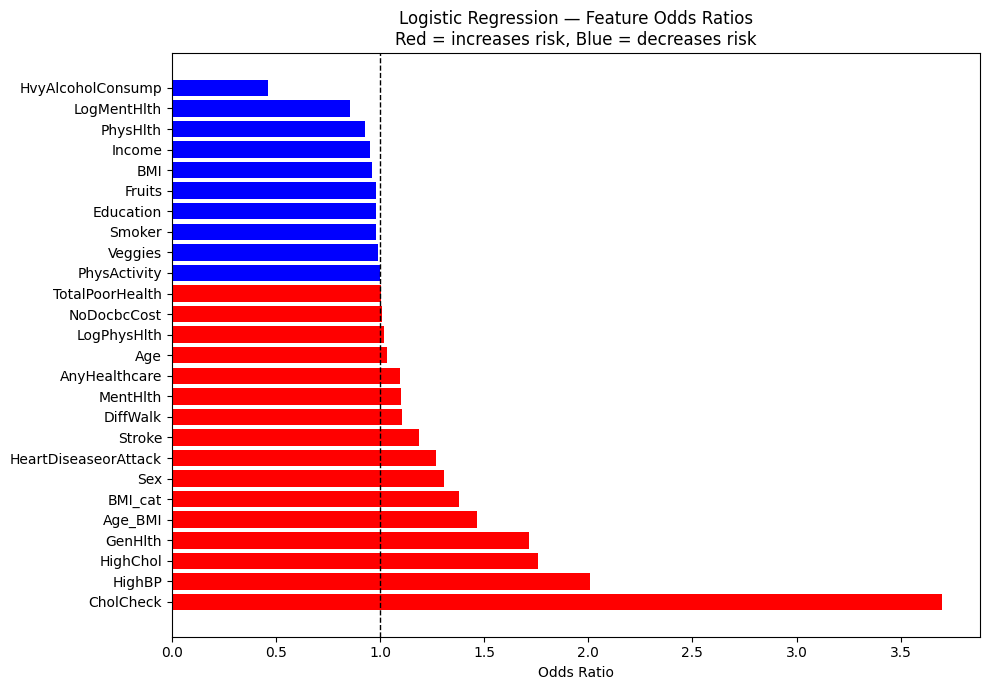

In [ ]:
colors = ['red' if v > 1 else 'blue' for v in or_df['Odds Ratio']]

plt.figure(figsize=(10, 7))
plt.barh(or_df['Feature'], or_df['Odds Ratio'], color=colors)
plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio')
plt.title('Logistic Regression — Feature Odds Ratios\nRed = increases risk, Blue = decreases risk')
plt.tight_layout()
plt.show()

## 9. XGBoost — SHAP Values

Tree models don't have simple coefficients. SHAP decomposes each prediction into per-feature contributions.

Positive SHAP = pushes toward diabetes. Negative = pushes away.

The bar chart shows mean absolute importance. The beeswarm shows direction and spread — red dots are high feature values, blue are low. Red concentrated on the right means higher values increase risk.

In [ ]:
sample_idx = np.random.choice(len(X_test), 2000, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.Explainer(xgb_model.predict_proba, X_sample)
shap_values = explainer(X_sample)

PermutationExplainer explainer: 2001it [01:29, 21.00it/s]                          


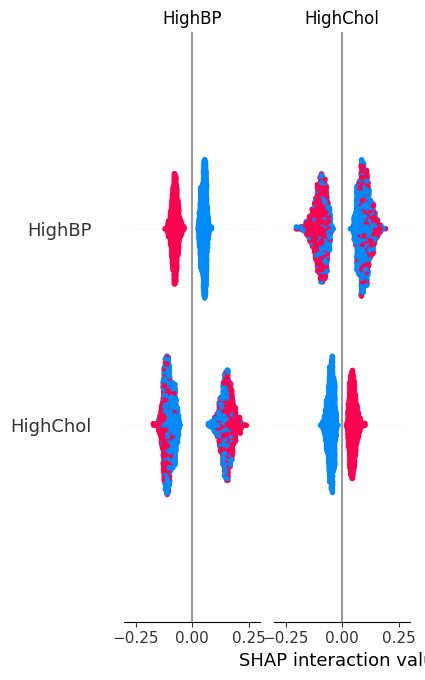

In [ ]:
shap.summary_plot(shap_values, X_sample, show=True)

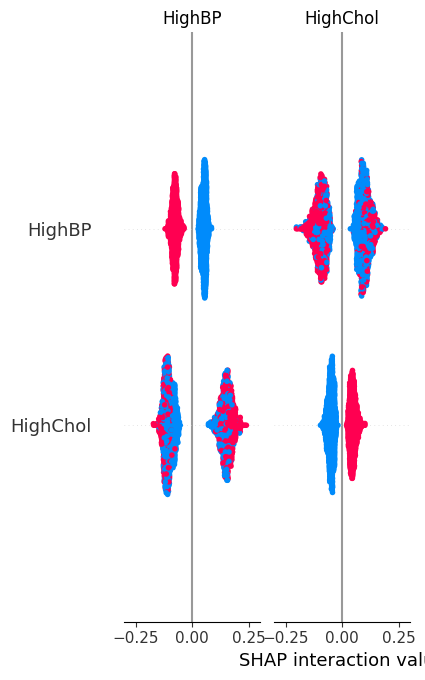

In [ ]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=True)

### SHAP — Individual & Subgroup Analysis

Beyond the global summary: what's driving the prediction for a specific high-risk patient? Do the same features dominate across income groups, or does the model explain itself differently for different populations?

PermutationExplainer explainer: 2001it [01:27, 20.47it/s]                          


Highest risk patient: predicted prob = 0.935
GenHlth     5.00000
BMI         1.37766
Age        11.00000
HighBP      1.00000


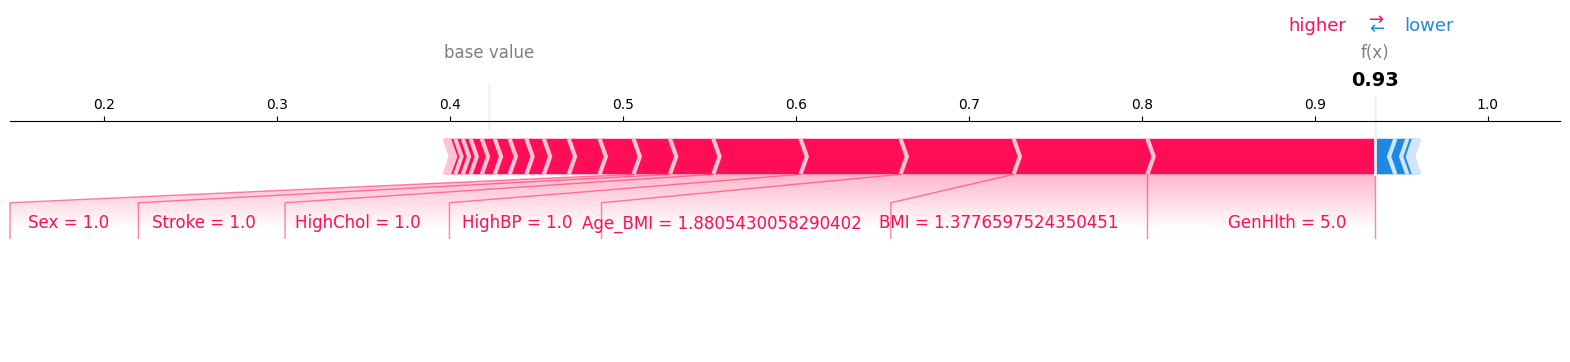


Top-3 SHAP features by income level (mean |SHAP|):
  Income=1: ['GenHlth', 'Age_BMI', 'HighBP']
  Income=4: ['GenHlth', 'Age_BMI', 'HighBP']
  Income=8: ['GenHlth', 'Age_BMI', 'HighBP']


In [ ]:
# sample
sample_idx = np.random.choice(len(X_test), 2000, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.Explainer(xgb_model.predict_proba, X_sample)
shap_values = explainer(X_sample)

shap_vals = shap_values.values[..., 1]
base_value = shap_values.base_values[..., 1]

# Highest-risk case
xgb_sample_probs = xgb_model.predict_proba(X_sample)[:, 1]
high_risk_idx = int(np.argmax(xgb_sample_probs))

print(f'Highest risk patient: predicted prob = {xgb_sample_probs[high_risk_idx]:.3f}')
print(X_sample.iloc[high_risk_idx][['GenHlth', 'BMI', 'Age', 'HighBP']].to_string())

# force plot
shap.force_plot(
    base_value[high_risk_idx],
    shap_vals[high_risk_idx],
    X_sample.iloc[high_risk_idx],
    matplotlib=True,
    show=True
)

# SHAP consistency across income groups
print()
print('Top-3 SHAP features by income level (mean |SHAP|):')

income_col = X_sample['Income'].values

for inc_level in [1, 4, 8]:
    mask = income_col == inc_level
    if mask.sum() < 10:
        continue

    mean_abs = np.abs(shap_vals[mask]).mean(axis=0)
    top3 = np.argsort(mean_abs)[::-1][:3]
    feats = [X_sample.columns[i] for i in top3]

    print(f'  Income={inc_level}: {feats}')

### SHAP Stability Across Folds

A feature that ranks #1 in fold 1 and #5 in fold 3 is not a reliable signal. We compute SHAP on each CV fold's held-out set and measure variance. High CV (std/mean) = attribution is unstable = treat with caution in clinical decisions.

PermutationExplainer explainer: 501it [00:21, 12.67it/s]                         


  Fold 1 done.


PermutationExplainer explainer: 501it [00:21, 12.73it/s]                         


  Fold 2 done.


PermutationExplainer explainer: 501it [00:21, 12.19it/s]                         


  Fold 3 done.


PermutationExplainer explainer: 501it [00:21, 12.56it/s]                         


  Fold 4 done.


PermutationExplainer explainer: 501it [00:21, 12.84it/s]                         


  Fold 5 done.

SHAP stability — top 10 features:
          Feature  Mean |SHAP|  Std  |SHAP|  CV (std/mean)
          GenHlth     0.094669     0.001089       0.011506
          Age_BMI     0.074799     0.000686       0.009173
           HighBP     0.060897     0.000982       0.016127
         HighChol     0.049438     0.001556       0.031466
              BMI     0.037370     0.001818       0.048643
              Sex     0.021086     0.000932       0.044180
           Income     0.018828     0.001060       0.056322
HvyAlcoholConsump     0.016376     0.001612       0.098407
        CholCheck     0.013852     0.002422       0.174847
              Age     0.012445     0.001340       0.107674

High CV = attribution varies across folds = less trustworthy signal.


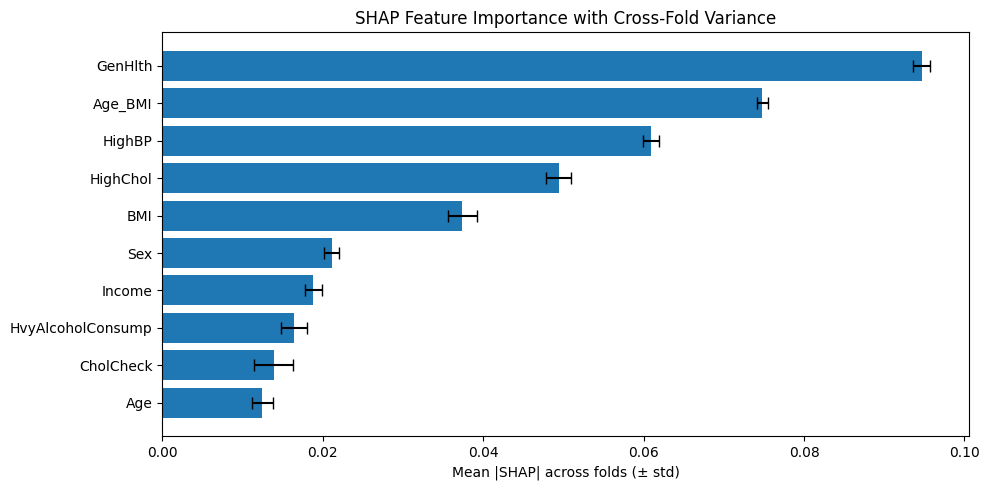

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

cv_shap = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_mean_abs = []

X_arr = X_train.reset_index(drop=True)
y_arr = y_train.reset_index(drop=True)

for fold_i, (tr_idx, val_idx) in enumerate(cv_shap.split(X_arr, y_arr)):
    Xf_tr, Xf_val = X_arr.iloc[tr_idx], X_arr.iloc[val_idx]
    yf_tr = y_arr.iloc[tr_idx]

    neg_f = (yf_tr == 0).sum()
    pos_f = (yf_tr == 1).sum()

    xgb_f = xgb.XGBClassifier(
        scale_pos_weight=neg_f / pos_f,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        base_score=0.5
    )

    xgb_f.fit(Xf_tr, yf_tr)

    samp = Xf_val.sample(min(500, len(Xf_val)), random_state=fold_i)

    # FINAL WORKING FIX: use callable predict_proba
    explainer = shap.Explainer(xgb_f.predict_proba, Xf_tr)
    sv = explainer(samp).values

    # take class 1 SHAP values
    sv = sv[:, :, 1]

    fold_mean_abs.append(np.abs(sv).mean(axis=0))
    print(f'  Fold {fold_i+1} done.')

fold_mean_abs = np.array(fold_mean_abs)
feat_names = X_train.columns.tolist()

mean_imp = fold_mean_abs.mean(axis=0)
std_imp = fold_mean_abs.std(axis=0)
cv_imp = std_imp / (mean_imp + 1e-9)

shap_stab_df = pd.DataFrame({
    'Feature': feat_names,
    'Mean |SHAP|': mean_imp,
    'Std  |SHAP|': std_imp,
    'CV (std/mean)': cv_imp
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print()
print('SHAP stability — top 10 features:')
print(shap_stab_df.head(10).to_string(index=False))
print()
print('High CV = attribution varies across folds = less trustworthy signal.')

top10 = shap_stab_df.head(10).iloc[::-1]

plt.figure(figsize=(10, 5))
plt.barh(
    top10['Feature'],
    top10['Mean |SHAP|'],
    xerr=top10['Std  |SHAP|'],
    capsize=4
)
plt.xlabel('Mean |SHAP| across folds (± std)')
plt.title('SHAP Feature Importance with Cross-Fold Variance')
plt.tight_layout()
plt.show()

### Logistic Regression — Coefficient Uncertainty

Odds ratios are point estimates. Bootstrap CI shows how much they shift across resamples. Features where the CI crosses 1.0 don't have a reliably signed effect.

Logistic Regression — Odds Ratios with 95% Bootstrap CI (top 15):
             Feature  OR mean  OR 2.5%  OR 97.5%
           CholCheck    3.739    3.211     4.399
              HighBP    2.008    1.938     2.072
            HighChol    1.755    1.704     1.812
             GenHlth    1.717    1.685     1.751
             Age_BMI    1.475    1.369     1.598
             BMI_cat    1.379    1.336     1.424
                 Sex    1.305    1.266     1.350
HeartDiseaseorAttack    1.268    1.216     1.324
              Stroke    1.189    1.121     1.256
            DiffWalk    1.105    1.058     1.152
            MentHlth    1.099    1.068     1.132
       AnyHealthcare    1.095    1.016     1.179
                 Age    1.029    1.004     1.052
         LogPhysHlth    1.019    0.984     1.053
         NoDocbcCost    1.007    0.954     1.070

Features where CI crosses 1.0 are not reliably directional.


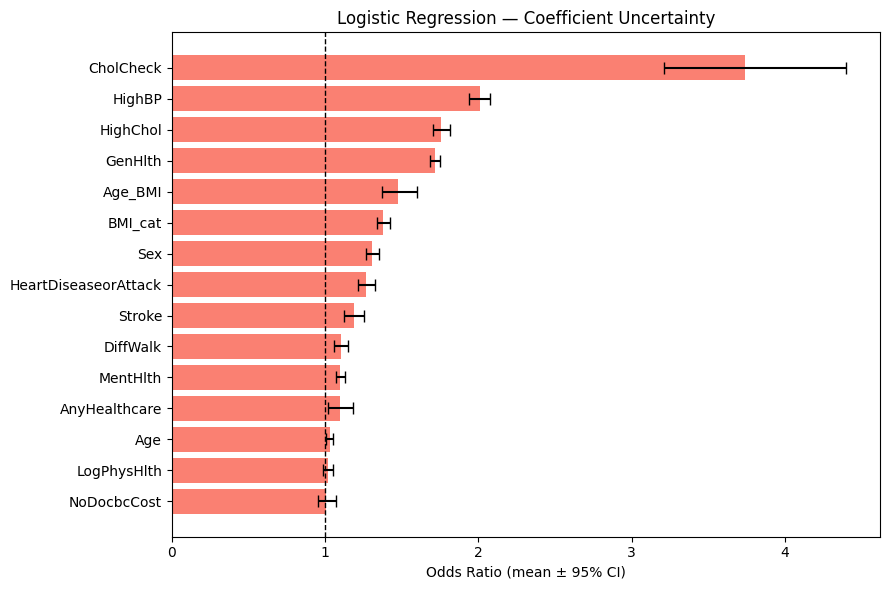

In [ ]:
n_boot_coef  = 300
boot_coefs   = []
feat_names_lr = X_train.columns.tolist()

X_tr_arr = X_train.reset_index(drop=True)
y_tr_arr  = y_train.reset_index(drop=True)
rng_coef  = np.random.RandomState(42)

for _ in range(n_boot_coef):
    idx = rng_coef.choice(len(X_tr_arr), len(X_tr_arr), replace=True)
    Xb  = X_tr_arr.iloc[idx]
    yb  = y_tr_arr.iloc[idx]
    lr_b = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    lr_b.fit(Xb, yb)
    boot_coefs.append(lr_b.coef_[0])

boot_coefs = np.array(boot_coefs)
coef_mean  = boot_coefs.mean(axis=0)
coef_lo, coef_hi = np.percentile(boot_coefs, [2.5, 97.5], axis=0)
or_mean = np.exp(coef_mean)
or_lo   = np.exp(coef_lo)
or_hi   = np.exp(coef_hi)

coef_df = pd.DataFrame({
    'Feature':  feat_names_lr,
    'OR mean':  or_mean,
    'OR 2.5%':  or_lo,
    'OR 97.5%': or_hi
}).sort_values('OR mean', ascending=False).reset_index(drop=True)

print('Logistic Regression — Odds Ratios with 95% Bootstrap CI (top 15):')
print(coef_df.head(15).round(3).to_string(index=False))
print()
print('Features where CI crosses 1.0 are not reliably directional.')

top15  = coef_df.head(15).iloc[::-1].reset_index(drop=True)
yerr_lo = (top15['OR mean'] - top15['OR 2.5%']).values
yerr_hi = (top15['OR 97.5%'] - top15['OR mean']).values

plt.figure(figsize=(9, 6))
plt.barh(top15['Feature'], top15['OR mean'],
         xerr=[yerr_lo, yerr_hi], color='salmon', capsize=4)
plt.axvline(1.0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio (mean ± 95% CI)')
plt.title('Logistic Regression — Coefficient Uncertainty')
plt.tight_layout()
plt.show()


## 11. Interaction Effects

Features looked at individually can hide interaction effects. Does BMI affect risk the same way at 25 vs 65? If the lines in the chart aren't parallel, the combination matters beyond each feature alone.

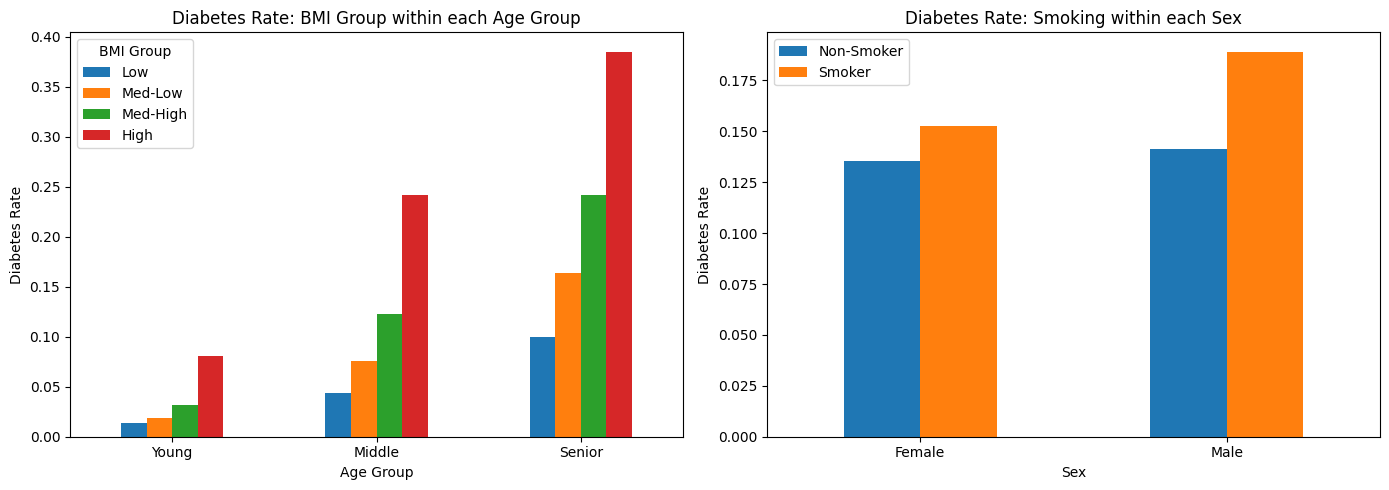

In [ ]:
plot_df = df.copy()
plot_df['BMI_group'] = pd.qcut(plot_df['BMI'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
plot_df['Age_group'] = pd.cut(plot_df['Age'], bins=[0, 4, 8, 13], labels=['Young', 'Middle', 'Senior'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI x Age interaction
pivot = plot_df.groupby(['Age_group', 'BMI_group'], observed=True)['Diabetes_binary'].mean().unstack()
pivot.plot(kind='bar', ax=axes[0])
axes[0].set_title('Diabetes Rate: BMI Group within each Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Diabetes Rate')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='BMI Group')

# Smoking x Sex interaction
pivot2 = plot_df.groupby(['Sex', 'Smoker'])['Diabetes_binary'].mean().unstack()
pivot2.index = ['Female', 'Male']
pivot2.columns = ['Non-Smoker', 'Smoker']
pivot2.plot(kind='bar', ax=axes[1])
axes[1].set_title('Diabetes Rate: Smoking within each Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Diabetes Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 12. Subgroup Fairness

A strong average metric can hide poor performance for specific groups. A model that works well for high-income patients but misses low-income diabetics reinforces existing health inequalities. This check should happen before any deployment decision.

### Equal Opportunity Gap

ROC-AUC by group is a start. The real question is whether we miss diabetes at the same rate across groups. A recall gap between income levels or age groups is a concrete harm, not just a statistical curiosity.

In [ ]:
audit_df = X_test.copy()
audit_df['y_true']     = y_test.values
audit_df['y_prob_xgb'] = scores['XGBoost']['proba']

print('XGBoost ROC-AUC by Income Group')
print('-' * 35)
for income in sorted(audit_df['Income'].unique()):
    group = audit_df[audit_df['Income'] == income]
    if len(group) > 100 and group['y_true'].nunique() > 1:
        auc = roc_auc_score(group['y_true'], group['y_prob_xgb'])
        print(f'  Income level {int(income)}: AUC = {auc:.3f}  (n={len(group)})')


XGBoost ROC-AUC by Income Group
-----------------------------------
  Income level 1: AUC = 0.770  (n=1966)
  Income level 2: AUC = 0.775  (n=2392)
  Income level 3: AUC = 0.789  (n=3215)
  Income level 4: AUC = 0.783  (n=3955)
  Income level 5: AUC = 0.805  (n=5083)
  Income level 6: AUC = 0.802  (n=6994)
  Income level 7: AUC = 0.813  (n=8120)
  Income level 8: AUC = 0.831  (n=14170)


In [ ]:
def equal_opp_gap(df_eval, group_col, prob_col='y_prob_xgb',
                   true_col='y_true', threshold=0.3):
    print(f'FNR by {group_col} (threshold={threshold})')
    print('-' * 50)
    recalls = {}
    for val in sorted(df_eval[group_col].unique()):
        grp = df_eval[df_eval[group_col] == val]
        if len(grp) < 50 or grp[true_col].nunique() < 2:
            continue
        preds = (grp[prob_col] >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(grp[true_col], preds).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fnr    = fn / (fn + tp) if (fn + tp) > 0 else 0
        recalls[val] = recall
        print(f'  {group_col}={int(val):2d}  recall={recall:.3f}  FNR={fnr:.3f}  n={len(grp)}')
    if recalls:
        v = list(recalls.values())
        print(f'  Equal Opp Gap: {max(v)-min(v):.3f}')

equal_opp_gap(audit_df, 'Income')
print()
audit_df['Age_grp'] = pd.cut(audit_df['Age'], bins=[0,4,8,13], labels=[1,5,9]).astype(float)
equal_opp_gap(audit_df, 'Age_grp')
print()
equal_opp_gap(audit_df, 'Sex')


FNR by Income (threshold=0.3)
--------------------------------------------------
  Income= 1  recall=0.940  FNR=0.060  n=1966
  Income= 2  recall=0.976  FNR=0.024  n=2392
  Income= 3  recall=0.953  FNR=0.047  n=3215
  Income= 4  recall=0.959  FNR=0.041  n=3955
  Income= 5  recall=0.943  FNR=0.057  n=5083
  Income= 6  recall=0.904  FNR=0.096  n=6994
  Income= 7  recall=0.897  FNR=0.103  n=8120
  Income= 8  recall=0.871  FNR=0.129  n=14170
  Equal Opp Gap: 0.105

FNR by Age_grp (threshold=0.3)
--------------------------------------------------
  Age_grp= 1  recall=0.513  FNR=0.487  n=7012
  Age_grp= 5  recall=0.887  FNR=0.113  n=16140
  Age_grp= 9  recall=0.958  FNR=0.042  n=22743
  Equal Opp Gap: 0.445

FNR by Sex (threshold=0.3)
--------------------------------------------------
  Sex= 0  recall=0.911  FNR=0.089  n=25531
  Sex= 1  recall=0.934  FNR=0.066  n=20364
  Equal Opp Gap: 0.023


In [ ]:
print("XGBoost ROC-AUC by Age Group")
print("-" * 35)
age_groups = [
    (1, 4,  'Young   (18–39)'),
    (5, 8,  'Middle  (40–59)'),
    (9, 13, 'Senior  (60+)  ')
]
for lo, hi, label in age_groups:
    group = audit_df[(audit_df['Age'] >= lo) & (audit_df['Age'] <= hi)]
    if len(group) > 100:
        auc = roc_auc_score(group['y_true'], group['y_prob_xgb'])
        print(f"  {label}: AUC = {auc:.3f}  (n={len(group)})")

XGBoost ROC-AUC by Age Group
-----------------------------------
  Young   (18–39): AUC = 0.831  (n=7012)
  Middle  (40–59): AUC = 0.827  (n=16140)
  Senior  (60+)  : AUC = 0.766  (n=22743)


## 12b. Robustness

Two stress tests:

1. **5% random bit-flips** on binary features — simulates survey entry errors.
2. **10% of BMI values set to mean** — simulates missing data at inference time, common in real deployments.

A small AUC drop (<0.01) is fine. A large drop means the model needs missing-value handling baked into training.

In [ ]:
binary_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke',
               'HeartDiseaseorAttack', 'PhysActivity', 'DiffWalk']

X_noisy = X_test.copy()
rng = np.random.RandomState(42)
for col in binary_cols:
    flip_mask = rng.rand(len(X_noisy)) < 0.05
    X_noisy.loc[flip_mask, col] = 1 - X_noisy.loc[flip_mask, col]

noisy_proba = xgb_model.predict_proba(X_noisy)[:, 1]
noisy_auc = roc_auc_score(y_test, noisy_proba)
clean_auc = scores['XGBoost']['ROC-AUC']
print(f'AUC clean: {clean_auc:.4f}  noisy (5% flip): {noisy_auc:.4f}  drop: {clean_auc-noisy_auc:.4f}')

X_missing = X_test.copy()
missing_mask = rng.rand(len(X_missing)) < 0.10
X_missing.loc[missing_mask, 'BMI'] = 0  # 0 = mean after standardisation
missing_proba = xgb_model.predict_proba(X_missing)[:, 1]
missing_auc = roc_auc_score(y_test, missing_proba)
print(f'AUC 10% BMI missing: {missing_auc:.4f}  drop: {clean_auc-missing_auc:.4f}')
print()
print('Small drop (<0.01) = robust. Large drop = need missing-value handling in training.')

AUC clean: 0.8181  noisy (5% flip): 0.8138  drop: 0.0042
AUC 10% BMI missing: 0.8177  drop: 0.0004

Small drop (<0.01) = robust. Large drop = need missing-value handling in training.


## 12c. Deployment Notes

**Feature availability:** all features here come from a self-reported survey. At a clinic you'd likely have BMI, age, sex, and basic vitals. `GenHlth` and `MentHlth` need a patient form — not always feasible at point of care.

**Data drift:** BRFSS is cross-sectional survey data. In production you'd monitor for distribution shifts — BMI trends, survey wording changes, demographic changes over time.

**What this model is:** a diagnostic proxy. It predicts current diabetes from current features, all measured at the same time. It's not a risk model. Actual risk prediction needs longitudinal data — features before diagnosis, outcome measured years later.

In [ ]:
# How much do we lose with only clinic-available features?
clinic_cols = ['BMI', 'Age', 'Sex', 'HighBP', 'HighChol']

xgb_clinic = xgb.XGBClassifier(
    scale_pos_weight=neg/pos, n_estimators=200, max_depth=5,
    learning_rate=0.1, random_state=42, verbosity=0
)
xgb_clinic.fit(X_train[clinic_cols], y_train)
clinic_proba = xgb_clinic.predict_proba(X_test[clinic_cols])[:, 1]
clinic_auc = roc_auc_score(y_test, clinic_proba)

print(f'Full model  ({len(X_train.columns):2d} features): AUC = {clean_auc:.4f}')
print(f'Clinic-only ({len(clinic_cols):2d} features): AUC = {clinic_auc:.4f}')
print(f'Cost of missing survey features: {clean_auc - clinic_auc:.4f}')
print()
print('If the gap is small, clinic-only deployment is viable and far more practical.')

Full model  (26 features): AUC = 0.8181
Clinic-only ( 5 features): AUC = 0.7798
Cost of missing survey features: 0.0383

If the gap is small, clinic-only deployment is viable and far more practical.


## 13. Summary

| Model | Best for |
|---|---|
| Logistic Regression | Explainability — odds ratios, clinical scoring rules |
| Random Forest | General use, handles messy/mixed data well |
| XGBoost | Best predictive performance; use SHAP to explain |

**On imbalance:** class weights, not SMOTE. Binary features can't be meaningfully interpolated.

**On causation:** this is survey data. Low physical activity being associated with diabetes doesn't mean exercise prevents it — people with diabetes may become less active. SHAP and odds ratios show association, not direction of cause. To reason causally you'd need a causal graph and proper confounder control.

**What this isn't:** a risk prediction model. It identifies current likely diabetics from current features. Predicting future onset needs a different dataset entirely.